# 1) Importando bibliotecas

In [55]:
import kagglehub
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from pathlib import Path
from matplotlib import pyplot as plt

# 2) Carregando os dados

In [56]:
print("Downloading dataset...")
path = kagglehub.dataset_download("rafaelsaraivacampos/25d-indoor-positioning-using-wifi-signals")
csv_files = sorted(list(Path(path).rglob('*.csv')))
print(f"Files: {csv_files}")
wifi_indoorLoc_points = pd.read_csv(csv_files[0])
rss_test = pd.read_csv(csv_files[1])
rss_train = pd.read_csv(csv_files[2])

Files: [PosixPath('/home/gabriel/.cache/kagglehub/datasets/rafaelsaraivacampos/25d-indoor-positioning-using-wifi-signals/versions/1/uerj_wifi_indoorLoc_points.csv'), PosixPath('/home/gabriel/.cache/kagglehub/datasets/rafaelsaraivacampos/25d-indoor-positioning-using-wifi-signals/versions/1/uerj_wifi_indoorLoc_test.csv'), PosixPath('/home/gabriel/.cache/kagglehub/datasets/rafaelsaraivacampos/25d-indoor-positioning-using-wifi-signals/versions/1/uerj_wifi_indoorLoc_train.csv')]


### 2.1) RSS test head

In [57]:
rss_test.head()

,scanId,point,RSS1,RSS2,RSS3,RSS4,RSS5,RSS6,RSS7,RSS8,...,RSS79,RSS80,RSS81,RSS82,RSS83,RSS84,RSS85,RSS86,RSS87,RSS88
0,41,1,-120.0,-120.0,-120,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0
1,42,1,-120.0,-120.0,-120,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0
2,43,1,-120.0,-120.0,-120,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0
3,44,1,-120.0,-120.0,-120,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0
4,45,1,-120.0,-120.0,-120,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0


### 2.2) RSS train head

In [58]:
rss_train.head()

,scanId,point,RSS1,RSS2,RSS3,RSS4,RSS5,RSS6,RSS7,RSS8,...,RSS79,RSS80,RSS81,RSS82,RSS83,RSS84,RSS85,RSS86,RSS87,RSS88
0,1,1,-120.0,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0
1,2,1,-120.0,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0
2,3,1,-120.0,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0
3,4,1,-120.0,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0
4,5,1,-120.0,-120.0,-120.0,-120,-120.0,-120.0,-120.0,-120.0,...,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0,-120.0


### 2.3) Pontos

In [59]:
wifi_indoorLoc_points.head()

,point,floor,X,Y,Z
0,1,4,0.0,17.15,-3.6
1,2,4,3.0,17.15,-3.6
2,3,4,6.0,17.15,-3.6
3,4,4,9.0,17.15,-3.6
4,5,4,12.0,17.15,-3.6


# 3) Análise dos dados

floor
4    272
5    282
6    262
Name: count, dtype: int64


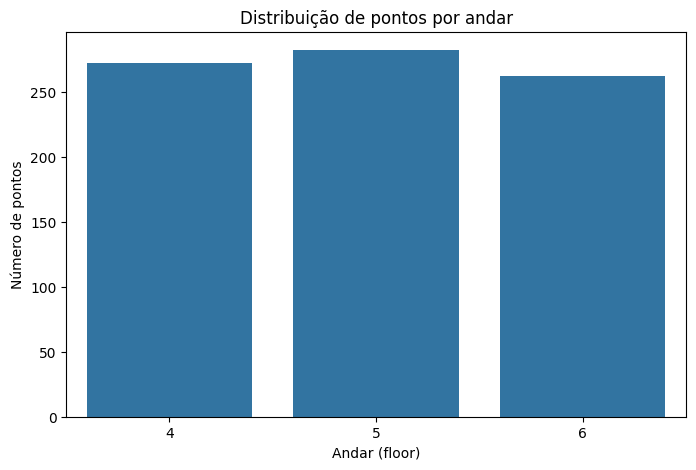

In [60]:
floor_counts = wifi_indoorLoc_points["floor"].value_counts().sort_index()
print(floor_counts)
plt.figure(figsize=(8, 5))
sns.barplot(x=floor_counts.index, y=floor_counts.values)
plt.xlabel("Andar (floor)")
plt.ylabel("Número de pontos")
plt.title("Distribuição de pontos por andar")
plt.show()

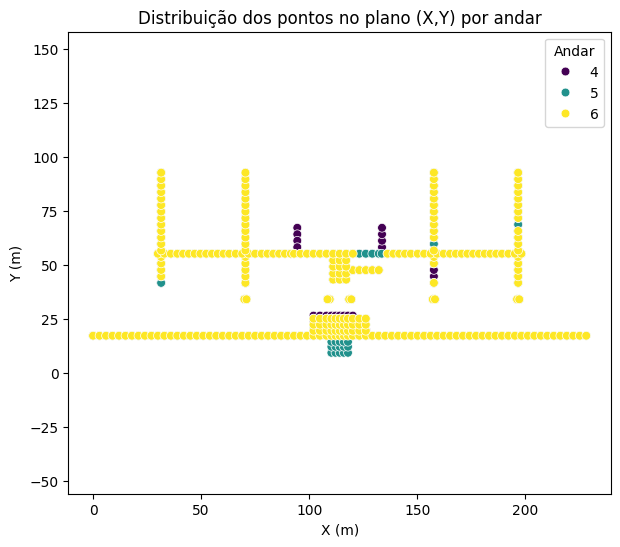

In [61]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=wifi_indoorLoc_points,
    x='X', y='Y',
    hue='floor',
    palette='viridis',
    s=40
)
plt.title("Distribuição dos pontos no plano (X,Y) por andar")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend(title="Andar")
plt.axis('equal')
plt.show()

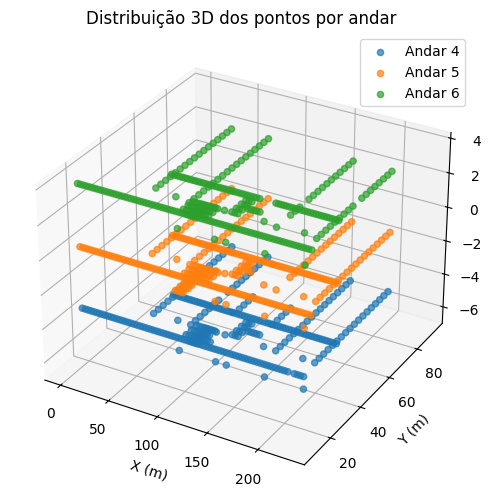

In [62]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

floors = sorted(wifi_indoorLoc_points['floor'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green']

for floor, color in zip(floors, colors):
    subset = wifi_indoorLoc_points[wifi_indoorLoc_points['floor'] == floor]
    ax.scatter(subset['X'], subset['Y'], subset['Z'], label=f"Andar {floor}", s=20, alpha=0.7, c=color)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Distribuição 3D dos pontos por andar')
ax.legend()
plt.show()

# 4) Juntando os dados

### Como o dataframe wifi_indoorLoc_points contém a informação do andar (nosso target), realizaremos um "inner join" utilizando a coluna point, presente em todos os datasets. Essa coluna identifica unicamente cada ponto de coleta, permitindo associar corretamente o andar correspondente aos seus respectivos valores de RSS (Received Signal Strength)

In [98]:
rss_train_with_target = rss_train.set_index('point').join(on='point', other=wifi_indoorLoc_points.set_index('point'))
X_train = rss_train_with_target.loc[:,'RSS1':'RSS88'].values
y_train = rss_train_with_target.loc[:,'floor'].values.reshape(-1)

rss_test_with_target = rss_test.set_index('point').join(on='point', other=wifi_indoorLoc_points.set_index('point'))
X_test = rss_test_with_target.loc[:,'RSS1':'RSS88'].values
y_test = rss_test_with_target.loc[:,'floor'].values.reshape(-1)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 5) Funções para plotar PCA e Matriz de Confusão

In [99]:
def display_confusion_matrix(y_true, y_pred_, colormap, classes):
    confusion = confusion_matrix(y_true, y_pred_)
    sns.heatmap(np.transpose(confusion), annot=True, cmap=colormap, cbar=False, square=True, ax=plt.axes(), xticklabels = classes, yticklabels = classes, fmt='d')
    plt.xlabel('Target Class')
    plt.ylabel('Predicted Class')


def plot_pca(pca,x_tick_min=0,x_tick_step=1):
    plt.figure()
    plt.plot(pca.explained_variance_ratio_)
    plt.ylabel('Variance')
    plt.xlabel('Principal Component')
    plt.title('Variance per component')
    plt.grid()
    plt.xlim(0,pca.n_components_-1)
    xticks = list(range(x_tick_min, pca.n_components_, x_tick_step))
    xticks.append(pca.n_components_-1)
    xticks.insert(0,0)
    plt.xticks(ticks=xticks, labels=[str(int(i)) for i in xticks+np.ones(len(xticks))])

    plt.figure()
    sums = [sum(pca.explained_variance_ratio_[:i+1]) for i in range(pca.n_components_)] 
    plt.plot(sums)
    plt.grid()
    plt.ylabel('Percentage of total variance')
    plt.xlabel('Number of PCs')
    plt.xlim(0,pca.n_components_-1)
    plt.title('Cummulative Variance')
    plt.xticks(ticks=xticks, labels=[str(int(i)) for i in xticks+np.ones(len(xticks))])


def test_model(mlp, X, y):
    y_pred = mlp.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f"Acurácia: {accuracy*100:.2f}%")
    print("Relatório de Classificação:")
    print(classification_report(y, y_pred))
    plt.figure(figsize=(8,6))
    display_confusion_matrix(y, y_pred, 'Blues', classes=sorted(np.unique(y)))
    plt.title("Matriz de Confusão - Classificador MLP")
    plt.show()

# 6) Verificando PCA dos dados

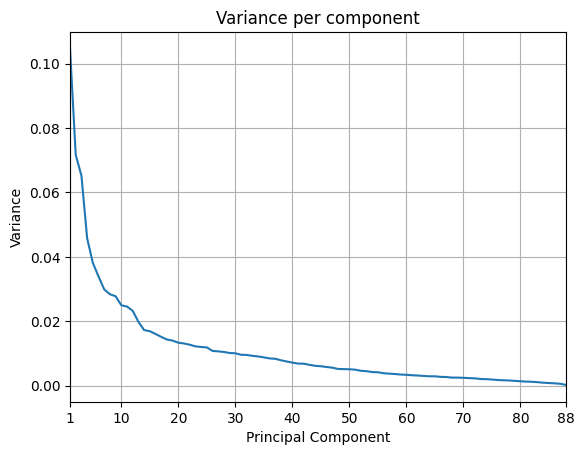

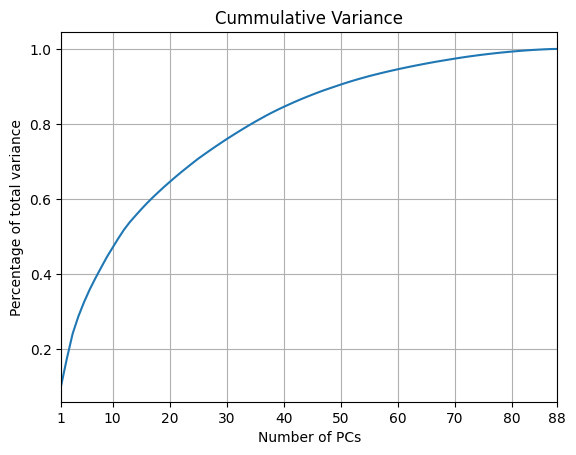

In [100]:
pca = PCA(n_components=X_train.shape[1], svd_solver='full').fit(X_train)
plot_pca(pca,9,10)

### A porcentagem de variância atingiu uma assíntota em torno de 60 variáveis. Nesse sentido, iremos reduzir o número de caracteríticas para esse valor.

# 7) Treinando um modelo MLP padrão

Acurácia: 96.89%
Relatório de Classificação:
              precision    recall  f1-score   support

           4       0.98      0.95      0.97      2720
           5       0.97      0.98      0.97      2820
           6       0.96      0.98      0.97      2620

    accuracy                           0.97      8160
   macro avg       0.97      0.97      0.97      8160
weighted avg       0.97      0.97      0.97      8160



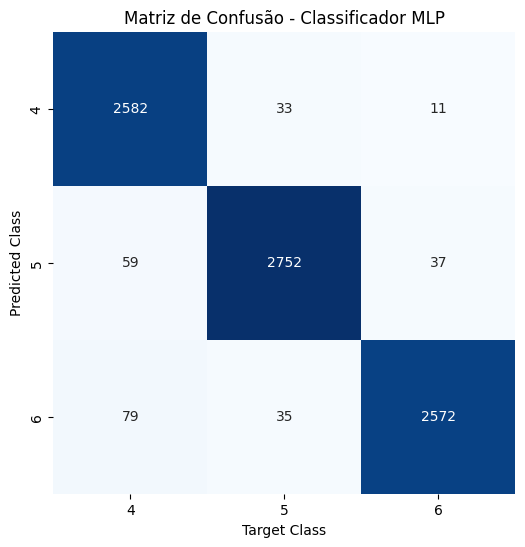

In [101]:
mlp = MLPClassifier(max_iter=500, random_state=42) # default hidden layer sizes=(100,)
mlp.fit(X_train, y_train)
test_model(mlp, X_test, y_test)

# 8) Validação do modelo

Acurácia: 97.55%
Relatório de Classificação:
              precision    recall  f1-score   support

           4       0.98      0.97      0.97      2158
           5       0.98      0.97      0.98      2295
           6       0.97      0.99      0.98      2075

    accuracy                           0.98      6528
   macro avg       0.98      0.98      0.98      6528
weighted avg       0.98      0.98      0.98      6528



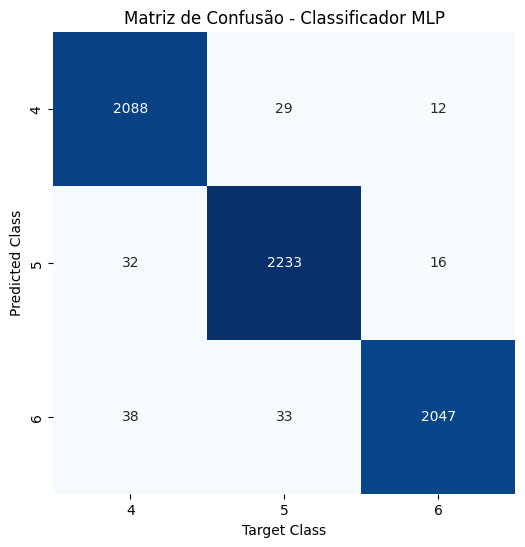

In [102]:
test_model(mlp, X_validation, y_validation)

# 9) Otimização do modelo com Grid Search (dados com PCA e sem PCA)

### Melhor modelo é armazenado em formato pickle

In [ ]:
number_of_principal_components = 60

pipeline = Pipeline([
    ('pca', PCA()),
    ('mlp', MLPClassifier(
        max_iter=800,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=15,
    )),
])

grid_params = [
    {
        'pca': ['passthrough', PCA(n_components=number_of_principal_components)],
        'mlp__hidden_layer_sizes': [
            (88,), (100,),
            (88, 44), (100, 50), (100, 88),
        ],
        'mlp__activation': ['relu', 'tanh'],
        'mlp__alpha': [1e-5, 1e-4, 1e-3],
        'mlp__learning_rate': ['constant', 'adaptive'],
        'mlp__learning_rate_init': [1e-3, 5e-4],
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    grid_params,
    cv=cv,
    n_jobs=-1,
    scoring='accuracy',
    refit=True
)

grid_search.fit(X_train, y_train)

print("\n===== Melhores hiperparâmetros =====")
print(grid_search.best_params_)
print(f"Melhor acurácia média em CV: {grid_search.best_score_:.4f}\n")

joblib.dump(grid_search.best_estimator_, 'best_mlp_model.pkl')
print("Modelo salvo como best_mlp_model.pkl")

Modelo salvo como best_mlp_model.pkl


Acurácia: 97.77%
Relatório de Classificação:
              precision    recall  f1-score   support

           4       0.99      0.96      0.98      2720
           5       0.98      0.99      0.98      2820
           6       0.96      0.98      0.97      2620

    accuracy                           0.98      8160
   macro avg       0.98      0.98      0.98      8160
weighted avg       0.98      0.98      0.98      8160



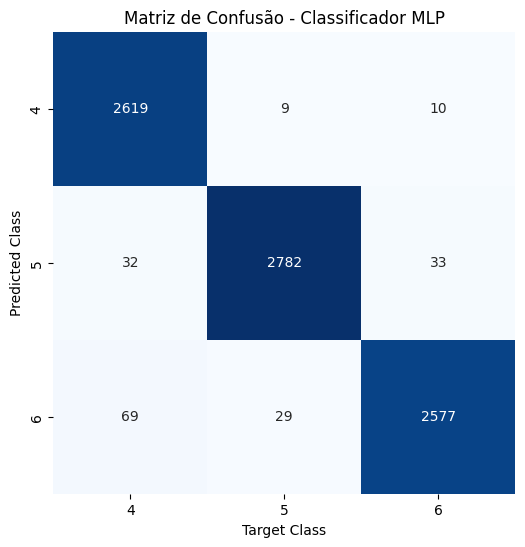

In [ ]:
model = joblib.load('best_mlp_model.pkl')
test_model(model, X_test, y_test)

# 10) Validando modelo otimizado

Acurácia: 98.38%
Relatório de Classificação:
              precision    recall  f1-score   support

           4       0.99      0.97      0.98      2158
           5       0.99      0.99      0.99      2295
           6       0.97      0.99      0.98      2075

    accuracy                           0.98      6528
   macro avg       0.98      0.98      0.98      6528
weighted avg       0.98      0.98      0.98      6528



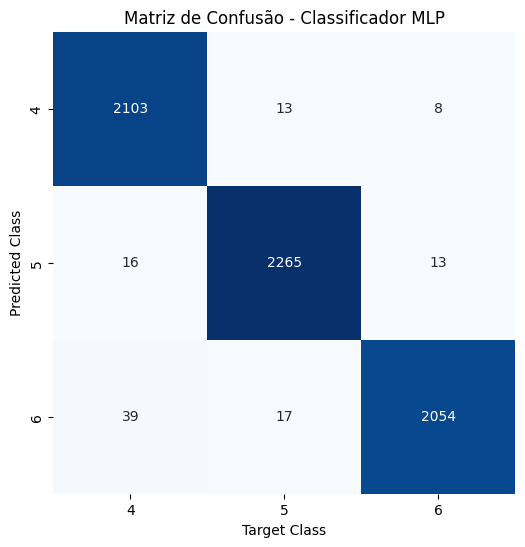

In [105]:
test_model(mlp, X_validation, y_validation)

# 11) Adicionando ruído

### Adicionando ruído lognormal ao conjunto de teste com desvio padrão 0.5 e médias de 0dB a 10dB

Ruído média=0.00dB | Acurácia: 75.51%
Ruído média=0.20dB | Acurácia: 66.89%
Ruído média=0.40dB | Acurácia: 56.16%
Ruído média=0.60dB | Acurácia: 48.55%
Ruído média=0.80dB | Acurácia: 43.39%
Ruído média=1.00dB | Acurácia: 39.28%
Ruído média=1.20dB | Acurácia: 37.56%
Ruído média=1.40dB | Acurácia: 36.63%
Ruído média=1.60dB | Acurácia: 35.71%
Ruído média=1.80dB | Acurácia: 35.33%
Ruído média=2.00dB | Acurácia: 35.38%
Ruído média=2.20dB | Acurácia: 35.32%
Ruído média=2.40dB | Acurácia: 35.07%
Ruído média=2.60dB | Acurácia: 34.88%
Ruído média=2.80dB | Acurácia: 34.74%
Ruído média=3.00dB | Acurácia: 34.74%
Ruído média=3.20dB | Acurácia: 34.68%
Ruído média=3.40dB | Acurácia: 34.60%
Ruído média=3.60dB | Acurácia: 34.61%
Ruído média=3.80dB | Acurácia: 34.60%
Ruído média=4.00dB | Acurácia: 34.56%
Ruído média=4.20dB | Acurácia: 34.56%
Ruído média=4.40dB | Acurácia: 34.57%
Ruído média=4.60dB | Acurácia: 34.56%
Ruído média=4.80dB | Acurácia: 34.56%
Ruído média=5.00dB | Acurácia: 34.56%
Ruído média=

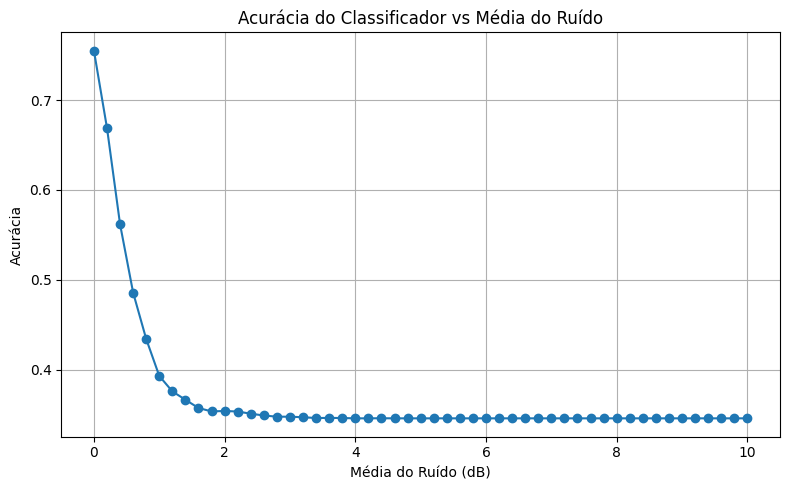

In [106]:
model = joblib.load('best_mlp_model.pkl')

noise_std = 0.5
noise_means = np.arange(0, 10.2, 0.2)
accuracies = []

for noise_mean in noise_means:
    X_test_copy = X_test.copy()

    noise = np.random.normal(loc=noise_mean, scale=noise_std, size=X_test_copy.shape)
    X_test_noisy = X_test_copy + noise
    y_pred = model.predict(X_test_noisy)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Ruído média={noise_mean:.2f}dB | Acurácia: {acc*100:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(noise_means, accuracies, marker="o")
plt.title("Acurácia do Classificador vs Média do Ruído")
plt.xlabel("Média do Ruído (dB)")
plt.ylabel("Acurácia")
plt.grid(True)
plt.tight_layout()
plt.show()